# Домашнее задание 3. Сверточные нейронные сети (CNN)

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1–4 | 3 (0.75 за задачу) |
| **Средние** | 5–7 | 3 (1 за задачу) |
| **Сложные** | 8–9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import matplotlib.patches as patches
import math

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cpu


---

## Теоретический минимум

### Почему для изображений нужны специальные архитектуры

Полносвязные сети (MLP) не учитывают пространственную структуру данных.
Для изображения размером $H \times W \times C$ полносвязный слой требует
$H \cdot W \cdot C \cdot N_{out}$ параметров, это быстро становится неуправляемым.

CNN используют три ключевые идеи:
- **Локальные связи**: каждый нейрон связан только с небольшой областью входа.
- **Разделение параметров** (parameter sharing): одно ядро применяется ко всем позициям.
- **Эквивариантность к сдвигу**: сдвиг входа приводит к аналогичному сдвигу карты признаков.

### Операция свертки

Дискретная двумерная свертка с ядром размера $K \times K$:

$$(f * g)(i, j) = \sum_{m=0}^{K-1}\sum_{n=0}^{K-1} f(m,n)\,g(i+m,\,j+n)$$

Результат — **карта признаков** (feature map).

### Формула размера выхода

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

где $P$ — padding, $K$ — размер ядра, $S$ — stride.

### Padding

- **valid** ($P=0$): размер уменьшается при каждой свертке.
- **same** ($P = \lfloor K/2 \rfloor$ при $S=1$): размер сохраняется.

### Stride

Шаг $S > 1$ уменьшает пространственное разрешение — альтернатива pooling.

### Pooling

- **Max Pooling** — берет максимум в окне (выделяет наиболее активный признак).
- **Average Pooling** — среднее в окне (сглаживает).

Pooling уменьшает разрешение и дает **локальную инвариантность** к малым сдвигам.

### Каналы и число параметров

Для свертки с $C_{in}$ входных и $C_{out}$ выходных каналов, ядром $K \times K$:

$$N_{params} = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$$

### Receptive field

Рецептивное поле — область входного изображения, влияющая на один элемент
выходной карты признаков. Растет с глубиной сети.

### Эквивариантность и инвариантность

- **Эквивариантность к сдвигу**: свертка гарантирует, что сдвиг входа порождает
  такой же сдвиг карты признаков.
- **Инвариантность**: достигается через pooling и глобальное усреднение.

### Задачи компьютерного зрения

| Задача | Вход | Выход |
|--------|------|-------|
| Классификация | Изображение | Метка класса |
| Детекция | Изображение | Bounding boxes + классы |
| Сегментация | Изображение | Маска (класс для каждого пикселя) |


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание базовых элементов CNN: свертка, padding, stride, pooling, подсчет параметров.

## Задача 1. Формула размера выхода свертки

### Постановка задачи

Реализуйте функцию, вычисляющую размер выхода сверточного/pooling слоя,
и проверьте ее на нескольких тестовых случаях.

**Формула:**
$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

### Задача
1. Реализуйте `conv_output_size(h_in, k, p, s)`.
2. Проверьте на 5 случаях: (32,3,0,1), (32,3,1,1), (32,5,0,2), (28,3,1,2), (224,7,3,2).
3. Реализуйте `pool_output_size` (по умолчанию stride = kernel_size).
4. Сверьте с `nn.Conv2d` / `nn.MaxPool2d`.


In [2]:
# Задача 1. Формула размера выхода свертки

def conv_output_size(h_in, k, p=0, s=1):
    """Вычисляет H_out по формуле"""
    assert "ваш код здесь"
    return math.trunc((h_in + 2*p - k) / s) + 1

def pool_output_size(h_in, k, p=0, s=None):
    """Размер выхода pooling (stride по умолчанию = kernel_size)."""
    assert "ваш код здесь"
    if s is None:
        s = k
    return math.trunc((h_in + 2*p - k) / s) + 1

# вы можете написать свою архитектуру эксперимента
print("Проверка формулы размера выхода свертки:")
print("-" * 65)

# --- Тестовые случаи (список множеств int) ---
# в кортежи добавлены значения exp
cases = [
    (32,3,0,1,30),
    (32,3,1,1,32),
    (32,5,0,2,14),
    (28,3,1,2,14),
    (224,7,3,2,112)
]

for i, (h, k, p, s, exp) in enumerate(cases, 1):
    # ваш код здесь
    print(f'Случай {i}')
    h_out = conv_output_size(h, k, p, s)
    print(f'Расчётный размер выхода слоя: {h_out}')
    if h_out == exp:
        print('Размер соответствует таргету')
    else:
        print('Размер не соответствует таргету')

# Проверка через PyTorch
print("\nСверка с PyTorch nn.Conv2d:")
print("-" * 65)

for i, (h, k, p, s, exp) in enumerate(cases, 1):
    # ваш код здесь

    # экспериментальный тензор
    X_t = torch.tensor(np.random.randn(1, 1, h, h).astype(np.float32), dtype=torch.float32)
    conv = nn.Conv2d(1, 1, k, padding=p, stride=s)
    X_t = conv(X_t)
    print(f'Расчётный размер выхода слоя: {X_t.shape[-1]}')
    if X_t.shape[-1] == exp:
        print('Размер соответствует таргету')
    else:
        print('Размер не соответствует таргету')


# Pooling
print("\nПроверка формулы размера выхода pooling:")
print("-" * 65)

# --- Тестовые случаи (список множеств int) ---
# в кортежи добавлены значения exp
cases = [
    (32,16),
    (28,14),
    (14,7),
    (7,3),
]

for i, (h, exp) in enumerate(cases, 1):
    # ваш код здесь
    print(f'Случай {i}')
    h_out = pool_output_size(h, k=2)
    print(f'Расчётный размер выхода слоя: {h_out}')
    if h_out == exp:
        print('Размер соответствует таргету')
    else:
        print('Размер не соответствует таргету')

print("\nРазмер после MaxPool2d(2) из PyTorch:")
print("-" * 65)
for i, (h, exp) in enumerate(cases, 1):
    # экспериментальный тензор
    X_t = torch.tensor(np.random.randn(1, 1, h, h).astype(np.float32), dtype=torch.float32)
    pool = nn.MaxPool2d(2)
    X_t = pool(X_t)
    print(f'Расчётный размер выхода слоя: {X_t.shape[-1]}')
    if X_t.shape[-1] == exp:
        print('Размер соответствует таргету')
    else:
        print('Размер не соответствует таргету')

Проверка формулы размера выхода свертки:
-----------------------------------------------------------------
Случай 1
Расчётный размер выхода слоя: 30
Размер соответствует таргету
Случай 2
Расчётный размер выхода слоя: 32
Размер соответствует таргету
Случай 3
Расчётный размер выхода слоя: 14
Размер соответствует таргету
Случай 4
Расчётный размер выхода слоя: 14
Размер соответствует таргету
Случай 5
Расчётный размер выхода слоя: 112
Размер соответствует таргету

Сверка с PyTorch nn.Conv2d:
-----------------------------------------------------------------
Расчётный размер выхода слоя: 30
Размер соответствует таргету
Расчётный размер выхода слоя: 32
Размер соответствует таргету
Расчётный размер выхода слоя: 14
Размер соответствует таргету
Расчётный размер выхода слоя: 14
Размер соответствует таргету
Расчётный размер выхода слоя: 112
Размер соответствует таргету

Проверка формулы размера выхода pooling:
-----------------------------------------------------------------
Случай 1
Расчётный разм

**Выводы:**  
1 Размер выхода слоя, расчитываемый функцией conv_output_size(), для всех примеров соответствует расчитанному вручную и размеру карты признаков из nn.Conv2d.  
2 Размер выхода слоя, расчитываемый функцией pool_output_size(), для всех примеров соответствует расчитанному вручную и размеру карты признаков из nn.MaxPool2d.

---

## Задача 2. Подсчет параметров свертки

### Постановка задачи

Сравните число параметров сверточного и полносвязного слоев при одинаковых
входных/выходных размерностях.

**Формулы:**
- Conv: $N = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$
- FC: $N = N_{in} \cdot N_{out} + N_{out}$

### Задача
1. Реализуйте `count_conv_params` и `count_fc_params`.
2. Сравните для входа 32x32x3 с выходом 32x32x16.
3. Покажите преимущество parameter sharing.


In [3]:
# Задача 2. Подсчет параметров свертки

def count_conv_params(c_in, c_out, k, bias=True):
    """Число параметров Conv2d."""
    assert "ваш код здесь"
    return k**2 * c_in * c_out + c_out

def count_fc_params(n_in, n_out, bias=True):
    """Число параметров Linear."""
    assert "ваш код здесь"
    return n_in*n_out + n_out

# --- Сравнение ---
# Вход: 32x32, 3 канала.  Выход: 32x32, 16 каналов.

conv_p = count_conv_params(3, 16, 3)
fc_p   = count_fc_params(32 * 32 * 3, 32 * 32 * 16)

print("Сравнение числа параметров:")
# ваш код здесь
print('--------------------------------------------------')
print(f'Conv2d(3, 16, kernel_size=3): {conv_p}')
print(f'Linear(3072, 16384): {fc_p}')
print(f'Отношение FC / Conv: {fc_p/conv_p}')

# Верификация через PyTorch
conv = nn.Conv2d(3, 16, 3)
fc = nn.Linear(32 * 32 * 3, 32 * 32 * 16)

conv_actual = sum(
    param.numel() for param in conv.parameters() if param.requires_grad
)
fc_actual = sum(
    param.numel() for param in fc.parameters() if param.requires_grad
)

print("\nПроверка через PyTorch:")
# ваш код и вывод здесь
print(f'Conv2d параметры: {conv_actual} (расчёт: {conv_p})')
print(f'Linear параметры: {fc_actual} (расчёт: {fc_p})')

Сравнение числа параметров:
--------------------------------------------------
Conv2d(3, 16, kernel_size=3): 448
Linear(3072, 16384): 50348032
Отношение FC / Conv: 112384.0

Проверка через PyTorch:
Conv2d параметры: 448 (расчёт: 448)
Linear параметры: 50348032 (расчёт: 50348032)


**Выводы:**  
1 Свертка с ядром 3x3 требует на несколько порядков
меньше параметров благодаря разделению весов (parameter sharing).

---

## Задача 3. CNN и отслеживание размерностей

### Постановка задачи

Постройте CNN для входа 1x28x28 (MNIST) и пропустите через нее случайный тензор,
выводя размерность на каждом слое.

### Архитектура
```
Input(1, 28, 28)
  -> Conv2d(1, 16, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Conv2d(16, 32, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Flatten
  -> Linear(32*7*7, 10)
```

### Задача
1. Реализуйте модель с печатью shape в forward.
2. Пропустите батч (4, 1, 28, 28) и проверьте размерности.
3. Выведите общее число параметров.


In [4]:
# Задача 3. CNN и отслеживание размерностей

class SimpleCNN(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features_1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.flat_t = nn.Flatten()
        self.features_2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.model_lin = nn.Linear(32*7*7, 10)


    def forward(self, x, verbose=False):
        assert "ваш код здесь"
        if verbose:
            print(f'Input: {x.shape}')
        x = self.features_1(x)
        if verbose:
            print(f'Conv1 + ReLU + Pool: {x.shape}')
        x = self.features_2(x)
        if verbose:
            print(f'Conv2 + ReLU + Pool: {x.shape}')
        x = self.flat_t(x)
        if verbose:
            print(f'Flatten: {x.shape}')
        x = self.model_lin(x)
        if verbose:
            print(f'FC (output):: {x.shape}')
        return x


model = SimpleCNN()
x = torch.randn(4, 1, 28, 28)

print("Прохождение тензора через сеть:")
# ваш код здесь
model.train()
y_pred_train = model.forward(x, verbose=True)

total_params = sum(param.numel() for param in model.parameters())
print(f"\nОбщее число параметров: {total_params:,}")


Прохождение тензора через сеть:
Input: torch.Size([4, 1, 28, 28])
Conv1 + ReLU + Pool: torch.Size([4, 16, 14, 14])
Conv2 + ReLU + Pool: torch.Size([4, 32, 7, 7])
Flatten: torch.Size([4, 1568])
FC (output):: torch.Size([4, 10])

Общее число параметров: 20,490


---

## Задача 4. Визуализация фильтров и карт признаков

### Постановка задачи

Создайте синтетическое изображение, примените к нему ручные фильтры
(детектор вертикальных краев, горизонтальных краев, размытие) и
визуализируйте результаты.

### Задача
1. Сгенерируйте изображение 28x28 с прямоугольником.
2. Определите три фильтра 3x3: вертикальные края, горизонтальные края, размытие.
3. Примените свертку (`F.conv2d`).
4. Визуализируйте оригинал и три карты признаков.


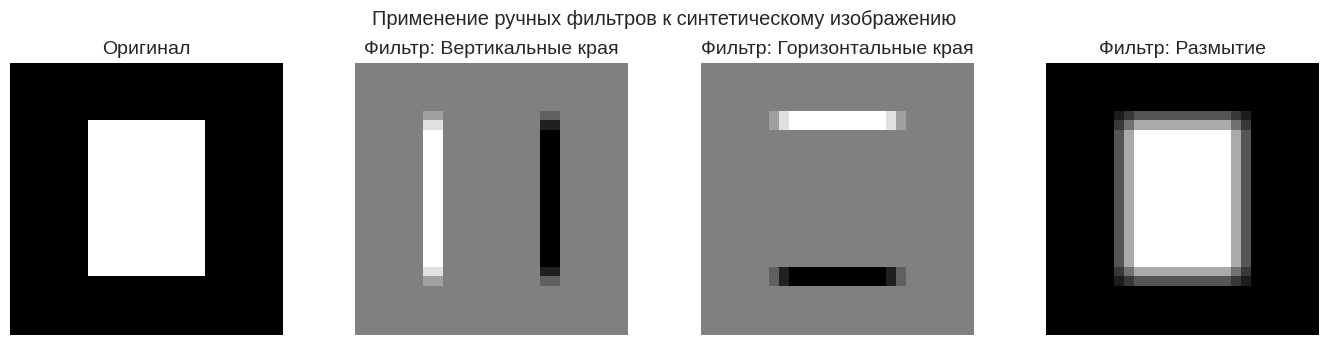

In [5]:
# Задача 4. Визуализация фильтров и карт признаков

# Синтетическое изображение: прямоугольник на черном фоне
img = np.zeros((28, 28), dtype=np.float32)
img[6:22, 8:20] = 1.0
img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # (1, 1, 28, 28)

# Фильтры 3x3
# ваш код здесь:

filters = {
    "Вертикальные края": torch.tensor([[[
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]]], dtype=torch.float32),

    "Горизонтальные края": torch.tensor([[[
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1],
    ]]], dtype=torch.float32),

    "Размытие": torch.ones(1, 1, 3, 3) / 9.0,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Оригинал")
axes[0].axis('off')

for i, (name, kernel) in enumerate(filters.items(), 1):
    with torch.no_grad():
        result = F.conv2d(img_tensor, kernel, padding=1)

    axes[i].imshow(result.squeeze(), cmap="gray")
    axes[i].set_title(f"Фильтр: {name}")
    axes[i].axis("off")

plt.suptitle("Применение ручных фильтров к синтетическому изображению")
plt.tight_layout()
plt.show()

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Комбинирование концепций: обучение CNN, абляционные эксперименты.

## Задача 5. Классификация FashionMNIST

### Постановка задачи

Обучите CNN-классификатор на датасете FashionMNIST.

### Архитектура
```
Conv2d(1,32,3,p=1)->ReLU->MaxPool(2)
->Conv2d(32,64,3,p=1)->ReLU->MaxPool(2)
->Flatten->Linear(64*7*7,128)->ReLU->Linear(128,10)
```

### Задача
1. Загрузите FashionMNIST, разделите train на train/val (50000/10000).
2. Обучите модель (10 эпох, Adam, lr=0.001, batch_size=64).
3. Постройте кривые обучения (loss, accuracy).
4. Выведите accuracy на тесте и confusion matrix.


100%|██████████| 26.4M/26.4M [00:01<00:00, 22.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 340kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.1MB/s]



Точность на тесте: 0.9173


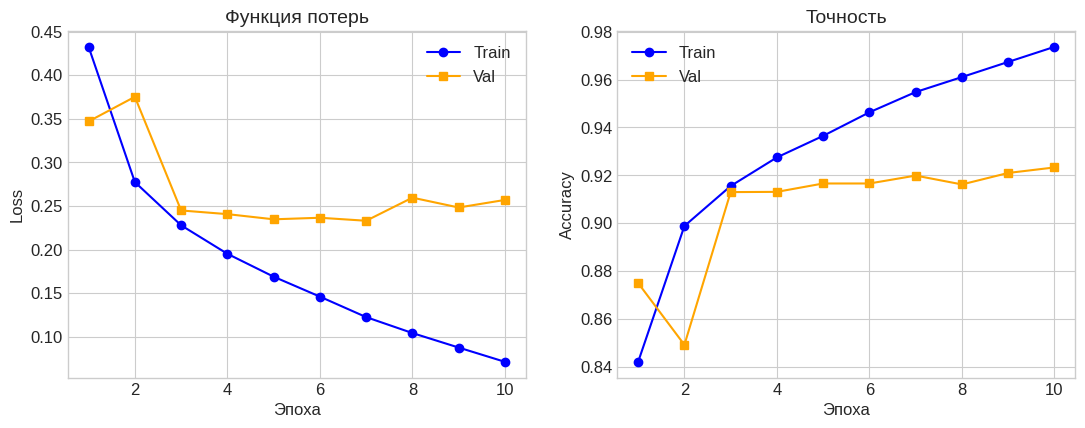

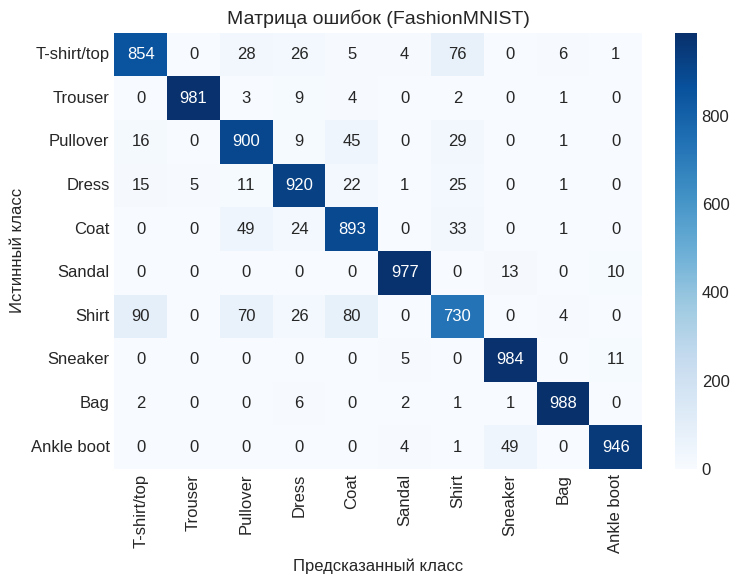

In [6]:
# Задача 5. Классификация FashionMNIST

torch.manual_seed(SEED)

# --- Данные ---
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_ds    = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_ds, val_ds = torch.utils.data.random_split(train_full, [50000, 10000],
                                                   generator=torch.Generator().manual_seed(SEED))

# TODO: Разбейте train_full на train и val (50000/10000)
train_set, val_set = train_ds, val_ds

# TODO: Создайте DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

# --- Модель ---
class FashionCNN(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )


    def forward(self, x):
        assert "ваш код здесь"
        return self.features(x)

model = FashionCNN().to(device)

# ваш код здесь:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Обучение ---
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model: nn.Module, loader, loss_fn, optimizer) -> tuple[float, float]:
    model.train()
    losses, accs, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        b = x.size(0)
        losses += loss.item() * b
        accs += accuracy_from_logits(logits, y) * b
        n += b
    return losses / n, accs / n

@torch.no_grad()
def evaluate(model: nn.Module, loader, loss_fn) -> tuple[float, float]:
    model.eval()
    losses, accs, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        b = x.size(0)
        losses += loss.item() * b
        accs += accuracy_from_logits(logits, y) * b
        n += b
    return losses / n, accs / n

for epoch in range(10):
    # Train
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)

    # Val
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)



# --- Графики ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, 11)

ax = axes[0]
ax.plot(
    epochs, history['train_loss'],
    color='blue', label='Train', marker='o'
)
ax.plot(
    epochs, history['val_loss'],
    color='orange', label='Val', marker='s'
)
ax.grid(True)
ax.legend()
ax.set_title("Функция потерь")
ax.set_xlabel("Эпоха"); ax.set_ylabel("Loss")

ax = axes[1]
ax.plot(
    epochs, history['train_acc'],
    color='blue', label='Train', marker='o'
)
ax.plot(
    epochs, history['val_acc'],
    color='orange', label='Val', marker='s'
)
ax.grid(True)
ax.legend()
ax.set_title("Точность")
ax.set_xlabel("Эпоха"); ax.set_ylabel("Accuracy")


# --- Тест ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # ваш код здесь
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.flatten().cpu().tolist())
        all_labels.extend(y_batch.flatten().cpu().tolist())


# можно написать свою реализацию вывода, можно использовать эту:

test_acc = accuracy_score(all_labels, all_preds)

print(f"\nТочность на тесте: {test_acc:.4f}")

# Confusion matrix
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс'); plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (FashionMNIST)'); plt.tight_layout(); plt.show()

**Выводы:**  
1 По построенным графикам точности и функции потерь наблюдается переобучение модели примерно после пятой эпохи. T.к. метрики на обучающей выборке продолжают улучшаться и после эпохи 5, а валидация не подтверждает существенного прироста точности или снижения Loss.

---

## Задача 6. MaxPool vs Strided Conv (абляция)

### Постановка задачи

Сравните два способа уменьшения пространственного разрешения:
MaxPool2d(2) и Conv2d с stride=2.

### Задача
1. Реализуйте две модели с одинаковой структурой, но разным downsampling.
2. Обучите обе на FashionMNIST (5 эпох).
3. Сравните: число параметров, test accuracy.
4. Постройте график accuracy обеих моделей.


--- Модель A: MaxPool ---
MaxPool эпоха 1/5 test_acc=0.7811
MaxPool эпоха 2/5 test_acc=0.7684
MaxPool эпоха 3/5 test_acc=0.7969
MaxPool эпоха 4/5 test_acc=0.8057
MaxPool эпоха 5/5 test_acc=0.8032

--- Модель B: Strided Conv ---
StridedConv эпоха 1/5 test_acc=0.8684
StridedConv эпоха 2/5 test_acc=0.8749
StridedConv эпоха 3/5 test_acc=0.8938
StridedConv эпоха 4/5 test_acc=0.9026
StridedConv эпоха 5/5 test_acc=0.9028

Параметры  MaxPool: 421642
Параметры  StridedConv: 421642
Accuracy   MaxPool: 0.8032
Accuracy   StridedConv: 0.9028


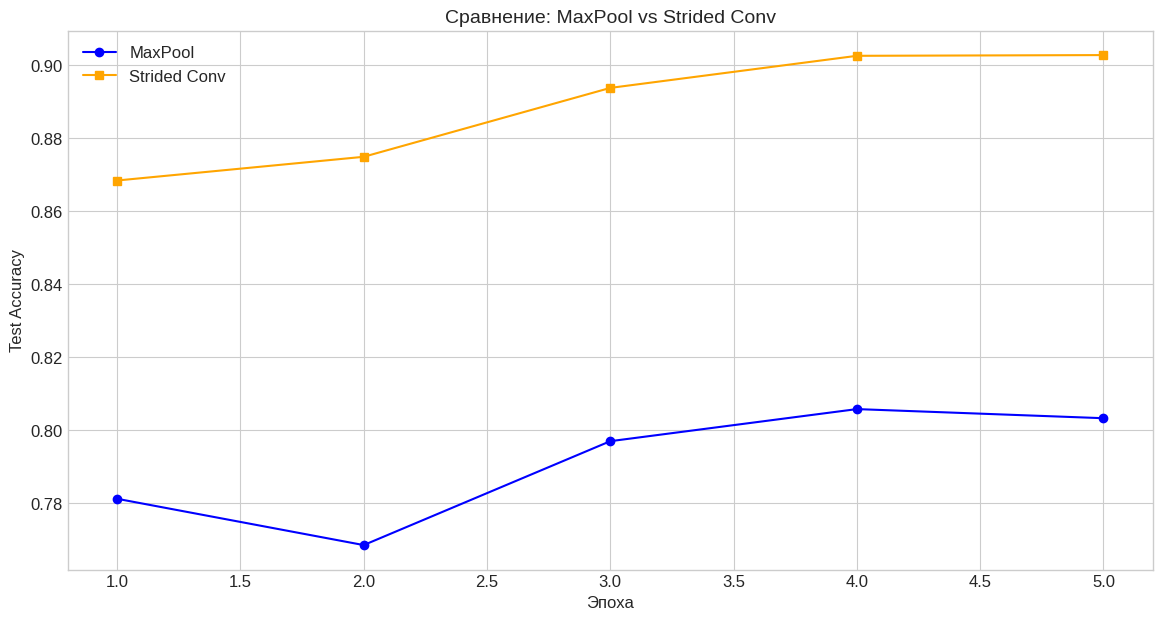

In [7]:
# Задача 6. MaxPool vs Strided Conv

torch.manual_seed(SEED)

class CNN_MaxPool(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features = nn.Sequential(
            nn.MaxPool2d(2),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(1*7*7, 830),
            nn.ReLU(),
            nn.Linear(830, 452),
            nn.ReLU(),
            nn.Linear(452, 10)
        )

    def forward(self, x):
        assert "ваш код здесь"
        return self.features(x)


class CNN_StridedConv(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self, x):
        assert "ваш код здесь"
        return self.features(x)

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_and_eval(model, name, loader_1, loader_2, loss_fn, epochs=5):
    assert "ваш код здесь"
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    accs_lst = []
    for epoch in range(epochs):
        model.train()
        for x, y in loader_1:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            accs, n = 0.0, 0
            for x, y in loader_2:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                b = x.size(0)
                accs += accuracy_from_logits(logits, y) * b
                n += b
            accs = accs / n
        accs_lst.append(accs)
        print(f'{name} эпоха {epoch+1}/{epochs} test_acc={accs:.4f}')
    return accs_lst

criterion = nn.CrossEntropyLoss()
print("--- Модель A: MaxPool ---")
m_a = CNN_MaxPool()
accs_a = train_and_eval(m_a, "MaxPool", train_loader, test_loader, criterion, 5)

print("\n--- Модель B: Strided Conv ---")
m_b = CNN_StridedConv()
accs_b = train_and_eval(m_b, "StridedConv", train_loader, test_loader, criterion, 5)

# ваш код здесь
p_a = sum(param.numel() for param in m_a.parameters())
p_b = sum(param.numel() for param in m_b.parameters())

print(f"\nПараметры  MaxPool: {p_a}")
print(f"Параметры  StridedConv: {p_b}")
print(f"Accuracy   MaxPool: {accs_a[-1]}")
print(f"Accuracy   StridedConv: {accs_b[-1]}")

# ваш код вывода графика здесь
plt.figure(figsize=(14, 7))
epochs = range(1, 6)
plt.plot(
    epochs, accs_a,
    color='blue', label='MaxPool', marker='o'
)
plt.plot(
    epochs, accs_b,
    color='orange', label='Strided Conv', marker='s'
)

plt.grid(True)
plt.legend()
plt.title("Сравнение: MaxPool vs Strided Conv")
plt.xlabel("Эпоха"); plt.ylabel("Test Accuracy")
plt.show()

**Выводы:**  
1 Под одинаковой структурой моделей понимаю одинаковое количество обучаемых параметров в них.  
2 Поскольку применение MaxPool не добавляет обучаемых параметров, то в архитектуре с MaxPool количество параметров было увеличено (до уровня модели с StridedConv) за счёт увеличения количества полносвязных слоёв и количеств нейронов в них. Требуемое количество нейронов в полносвязных слоях было определено подбором.  
3 Test Accuracy модели с StridedConv получился выше. Возможно, близкое значение Test Accuracy для модели с MaxPool могло бы быть достигнуто оптимизацией полносвязных слоёв последней.

---

## Задача 7. Эксперимент с padding: same vs valid

### Постановка задачи

Сравните влияние padding на качество классификации и размер карт признаков.

### Задача
1. Модель A: padding=1 (same) во всех свертках.
2. Модель B: padding=0 (valid).
3. Обучите обе на FashionMNIST (5 эпох).
4. Сравните размеры промежуточных тензоров и accuracy.


In [8]:
# Задача 7. Padding same vs valid

torch.manual_seed(SEED)

class CNN_Same(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self, x):
        assert "ваш код здесь"
        return self.features(x)


class CNN_Valid(nn.Module):
    def __init__(self):
        assert "ваш код здесь"
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # Учёт в размерах изображений padding=0
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self, x):
        assert "ваш код здесь"
        return self.features(x)


# Проверка размерностей
x_test = torch.randn(1, 1, 28, 28)

# замените троеточия на ваш код
print("Размерности карт признаков:")
print(f"  Same (p=1):  Conv1-> {CNN_Same().features[:3](x_test).shape}  Conv2-> {CNN_Same().features[:6](x_test).shape}")
print(f"  Valid (p=0): Conv1-> {CNN_Valid().features[:3](x_test).shape}  Conv2-> {CNN_Valid().features[:6](x_test).shape}")


criterion = nn.CrossEntropyLoss()
print("\n--- Модель Same (padding=1) ---")
m_same = CNN_Same()
accs_same = train_and_eval(m_same, "Same", train_loader, test_loader, criterion, 5)

print("\n--- Модель Valid (padding=0) ---")
m_valid = CNN_Valid()
accs_valid = train_and_eval(m_valid, "Valid", train_loader, test_loader, criterion, 5)

print(f"\nAccuracy  Same:  {accs_same[-1]}")
print(f"Accuracy  Valid: {accs_valid[-1]}")

Размерности карт признаков:
  Same (p=1):  Conv1-> torch.Size([1, 32, 14, 14])  Conv2-> torch.Size([1, 64, 7, 7])
  Valid (p=0): Conv1-> torch.Size([1, 32, 13, 13])  Conv2-> torch.Size([1, 64, 5, 5])

--- Модель Same (padding=1) ---
Same эпоха 1/5 test_acc=0.8742
Same эпоха 2/5 test_acc=0.8990
Same эпоха 3/5 test_acc=0.8986
Same эпоха 4/5 test_acc=0.9117
Same эпоха 5/5 test_acc=0.9152

--- Модель Valid (padding=0) ---
Valid эпоха 1/5 test_acc=0.8551
Valid эпоха 2/5 test_acc=0.8651
Valid эпоха 3/5 test_acc=0.8962
Valid эпоха 4/5 test_acc=0.9025
Valid эпоха 5/5 test_acc=0.9047

Accuracy  Same:  0.9152
Accuracy  Valid: 0.9047


**Выводы:**  
1 Вывод: padding=0 уменьшает размер карт признаков, что приводит к потере информации на краях изображения. Этим могут объясняться несколько меньшие значения Accuracy у модели с padding=0, по сравнению с моделью, у которой padding=1.  
2 Данный эффект может быть критичным для глубоких сетей.

---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Детекция и сегментация на синтетических данных.

## Задача 8. Toy Detection: регрессия Bounding Box

### Постановка задачи

Генерируются синтетические 64x64 изображения с одним прямоугольником
в случайной позиции. Модель предсказывает координаты Bounding Box.

### Задача
1. Сгенерируйте 1000 train и 200 test изображений.
2. Реализуйте CNN для регрессии: выход — 4 числа (x, y, w, h), нормализованных в [0, 1].
3. Loss: MSE.  Метрика: IoU.
4. Обучите 30 эпох.
5. Визуализируйте 6 примеров с истинным и предсказанным bbox.


Train: torch.Size([1000, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])
Epoch  1/30  train_loss=0.017196  test_iou=0.5905
Epoch  2/30  train_loss=0.002843  test_iou=0.6692
Epoch  3/30  train_loss=0.001480  test_iou=0.7523
Epoch  4/30  train_loss=0.000646  test_iou=0.7578
Epoch  5/30  train_loss=0.000421  test_iou=0.8277
Epoch  6/30  train_loss=0.000231  test_iou=0.8244
Epoch  7/30  train_loss=0.000214  test_iou=0.8318
Epoch  8/30  train_loss=0.000268  test_iou=0.8495
Epoch  9/30  train_loss=0.000163  test_iou=0.8445
Epoch 10/30  train_loss=0.000128  test_iou=0.8768
Epoch 11/30  train_loss=0.000113  test_iou=0.8775
Epoch 12/30  train_loss=0.000081  test_iou=0.8813
Epoch 13/30  train_loss=0.000069  test_iou=0.8844
Epoch 14/30  train_loss=0.000126  test_iou=0.8652
Epoch 15/30  train_loss=0.000114  test_iou=0.8587
Epoch 16/30  train_loss=0.000126  test_iou=0.8677
Epoch 17/30  train_loss=0.000154  test_iou=0.8730
Epoch 18/30  train_loss=0.000124  test_iou=0.8787
Epoch 19/30  train_loss=0.0

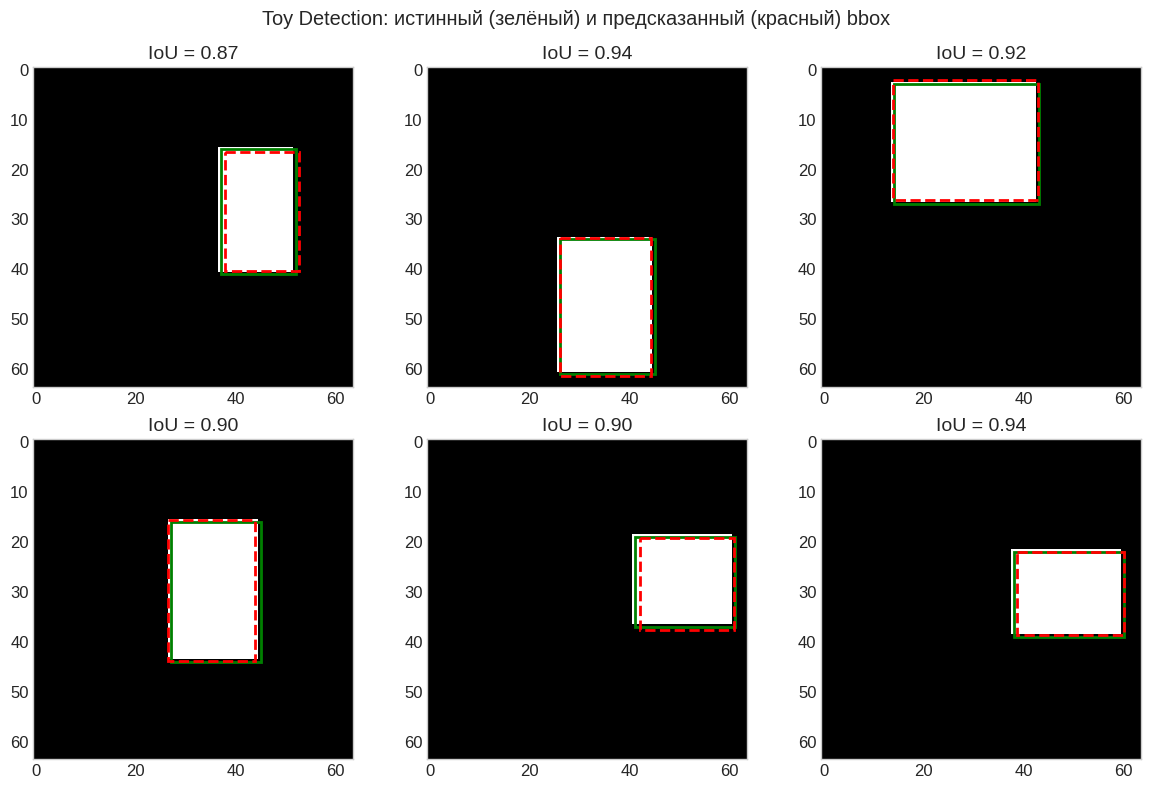


Средний IoU на тесте: 0.8908


In [14]:
# Задача 8. Toy Detection

torch.manual_seed(SEED)
np.random.seed(SEED)

# Константы
IMG_SIZE = 64
N_TRAIN = 1000
N_TEST = 200
BATCH_SIZE = 32
N_EPOCHS = 30

def generate_detection_data(n, img_size=IMG_SIZE):
    """Генерация изображений с одним прямоугольником и bbox-метками."""
    images, boxes = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        w = np.random.randint(10, 30)
        h = np.random.randint(10, 30)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)
        img[y:y+h, x:x+w] = 1.0
        mask = [x, y, w, h]
        images.append(img)

        # Нормализованный bbox: (x, y, w, h) в [0,1]
        boxes.append([x / img_size, y / img_size, w / img_size, h / img_size])
    X = torch.tensor(np.array(images), dtype=torch.float32).unsqueeze(1)  # (N, 1, H, W)
    Y = torch.tensor(np.array(boxes), dtype=torch.float32) # (N, 4) в [0,1]
    return X, Y

# Данные
X_train, Y_train = generate_detection_data(N_TRAIN)
X_test,  Y_test  = generate_detection_data(N_TEST)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_det_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)

# --- IoU --- вычисление для нормализованных bbox
def compute_iou_norm(preds, targets, img_size=IMG_SIZE):
    """
    preds и targets могут быть:
      - torch.Tensor формы (N, 4) или (4,)
      - numpy.ndarray формы (N, 4) или (4,)
    Возвращает средний IoU по батчу или по одному примеру (если переданы 1 элемент)
    """

    # Преобразуем вход в тензоры
    if isinstance(preds, np.ndarray):
        preds = torch.from_numpy(preds)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)

    if preds.dim() == 1:
        preds = preds.unsqueeze(0)
    if targets.dim() == 1:
        targets = targets.unsqueeze(0)

    preds = preds.detach().cpu()
    targets = targets.detach().cpu()

    ious = []
    for p, t in zip(preds, targets):
        x1, y1, w1, h1 = p.tolist()
        x2, y2, w2, h2 = t.tolist()

        # восстановление размеров
        rec_x1 = x1 * img_size
        rec_y1 = y1 * img_size
        rec_w1 = w1 * img_size
        rec_h1 = h1 * img_size
        rec_x2 = x2 * img_size
        rec_y2 = y2 * img_size
        rec_w2 = w2 * img_size
        rec_h2 = h2 * img_size

        inter_x1 = max(rec_x1, rec_x2)
        inter_y1 = max(rec_y1, rec_y2)
        inter_x2 = min(rec_x1 + rec_w1, rec_x2 + rec_w2)
        inter_y2 = min(rec_y1 + rec_h1, rec_y2 + rec_h2)

        # Ширина и высота пересечения
        inter_w = max(0, inter_x2 - inter_x1)
        inter_h = max(0, inter_y2 - inter_y1)

        # Площади
        intersection_area = inter_w * inter_h
        union_area = (rec_w1 * rec_h1) + (rec_w2 * rec_h2) - intersection_area

        # IoU
        iou = intersection_area / max(union_area, 1e-6)
        ious.append(iou)
    return float(np.mean(ious))


# --- Модель ---
class DetectionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.sigmoid(x)  # нормализация в [0,1]
        return x


model_det = DetectionCNN().to(device)
optimizer = optim.Adam(model_det.parameters(), lr=0.003)
criterion = nn.MSELoss()

# --- Обучение ---
for epoch in range(1, N_EPOCHS + 1):
    # ваш код здесь
    model_det.train()
    epoch_loss = 0.0
    for x, y in train_det_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        preds = model_det(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)

    train_loss = epoch_loss / len(train_det_loader.dataset)


    # Оценка IoU на тесте
    model_det.eval()
    with torch.no_grad():
        preds_test = model_det(X_test.to(device))
        test_iou = compute_iou_norm(preds_test, Y_test, img_size=IMG_SIZE)

    print(f"Epoch {epoch:2d}/{N_EPOCHS}  train_loss={train_loss:.6f}  test_iou={test_iou:.4f}")


# --- Визуализация 6 примеров ---

model_det.eval()
with torch.no_grad():
    samples = 6
    preds6_t = model_det(X_test[:samples].to(device)).cpu()   # tensor (samples, 4)
    truths6_t = Y_test[:samples].cpu()                        # tensor (samples, 4)

# Для визуализации numpy-версии координат
preds6_np = preds6_t.numpy()
truths6_np = truths6_t.numpy()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
k=0
for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        img = X_test[k].squeeze().cpu().numpy()
        ax.imshow(img, cmap="gray")

        # Истинный bbox (пиксели)
        x_true = truths6_np[k, 0] * IMG_SIZE
        y_true = truths6_np[k, 1] * IMG_SIZE
        w_true = truths6_np[k, 2] * IMG_SIZE
        h_true = truths6_np[k, 3] * IMG_SIZE
        green_rect = patches.Rectangle(
            (x_true, y_true), w_true, h_true,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(green_rect)

        # Предсказанный bbox (пиксели)
        x_pred = preds6_np[k, 0] * IMG_SIZE
        y_pred = preds6_np[k, 1] * IMG_SIZE
        w_pred = preds6_np[k, 2] * IMG_SIZE
        h_pred = preds6_np[k, 3] * IMG_SIZE
        red_rect = patches.Rectangle(
            (x_pred, y_pred), w_pred, h_pred,
            linewidth=2,
            edgecolor='red',
            facecolor='none',
            linestyle='--'
        )
        ax.add_patch(red_rect)

        # IoU для пары (используем тензорные границы)
        iou_k = compute_iou_norm(preds6_t[k:k+1], truths6_t[k:k+1], img_size=IMG_SIZE)
        ax.set_title(f"IoU = {iou_k:.2f}")
        ax.grid(False)
        k += 1

plt.suptitle("Toy Detection: истинный (зелёный) и предсказанный (красный) bbox")
plt.tight_layout(); plt.show()

# Общий IoU по тесту
final_iou = compute_iou_norm(model_det(X_test.to(device)), Y_test, img_size=IMG_SIZE)
print(f"\nСредний IoU на тесте: {final_iou:.4f}")

---

## Задача 9. Toy Segmentation: мини encoder-decoder

### Постановка задачи

Реализуйте сеть типа encoder-decoder со Skip Connections для бинарной
сегментации синтетических изображений.

### Задача
1. Сгенерируйте 800 train и 200 test пар (изображение, маска) с кругами/прямоугольниками.
2. Encoder: 3 уровня (Conv+ReLU+MaxPool).
3. Decoder: 3 уровня (ConvTranspose + Skip Connection + Conv+ReLU).
4. Loss: BCEWithLogitsLoss.  Метрики: IoU, Dice.
5. Обучите 30 эпох.
6. Визуализируйте 6 примеров: вход, истинная маска, предсказанная маска.


Train: torch.Size([800, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])


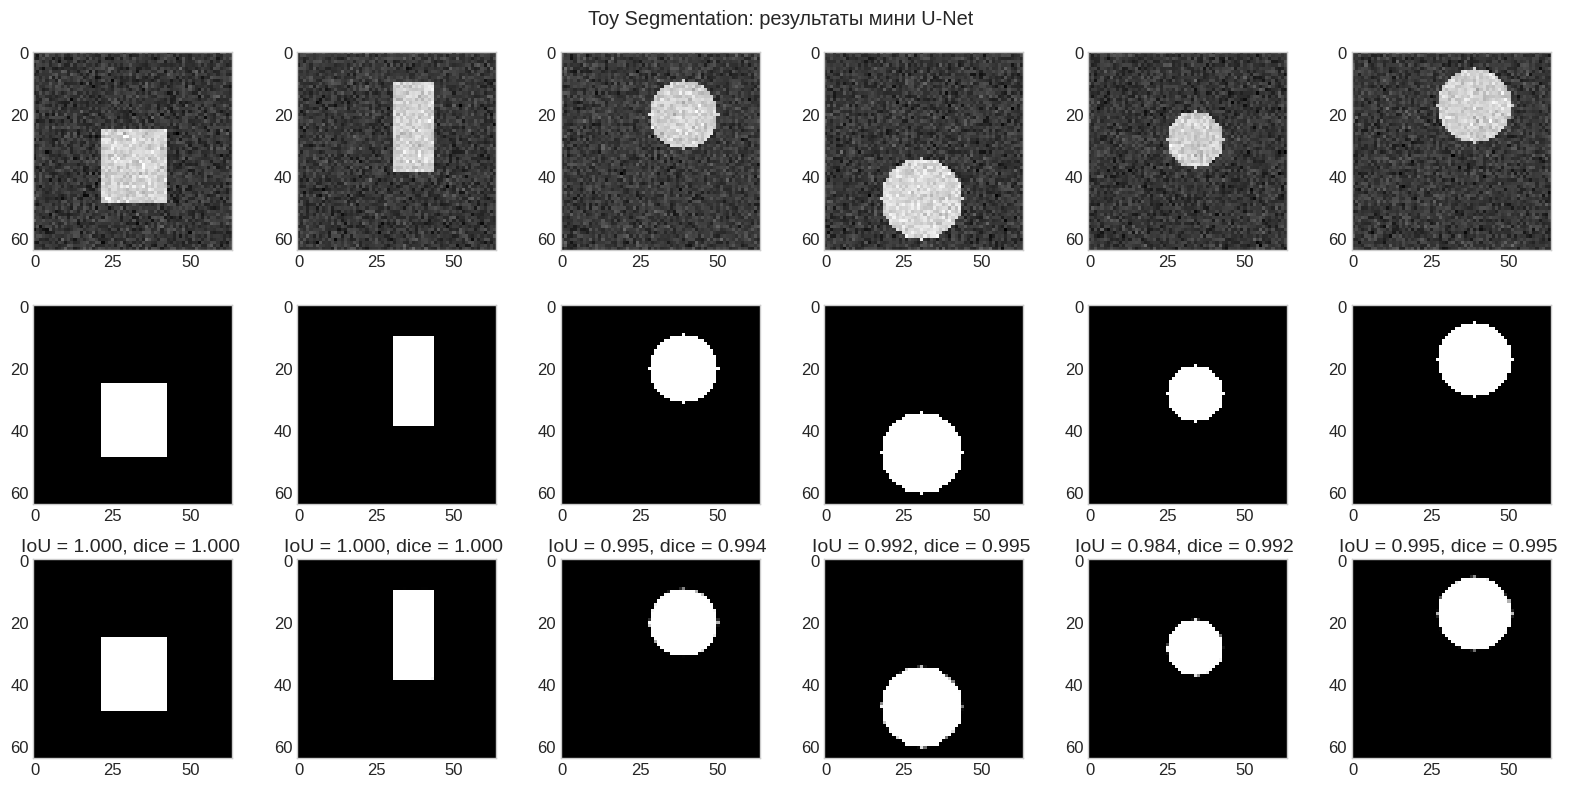


Средний IoU  на тесте: 0.9945
Средний Dice на тесте: 0.9957


In [ ]:
# Задача 9. Toy Segmentation: мини encoder-decoder

torch.manual_seed(SEED)
np.random.seed(SEED)

def generate_segmentation_data(n, img_size=64):
    """Генерация изображений с фигурами и бинарных масок."""
    images, masks = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        mask = np.zeros((img_size, img_size), dtype=np.float32)
        # Случайный круг или прямоугольник
        if np.random.rand() > 0.5:
            # Круг
            cx, cy = np.random.randint(15, img_size - 15, size=2)
            r = np.random.randint(5, 15)
            yy, xx = np.ogrid[:img_size, :img_size]
            circle = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[circle] = 1.0
            mask[circle] = 1.0
        else:
            # Прямоугольник
            w = np.random.randint(10, 30)
            h = np.random.randint(10, 30)
            x = np.random.randint(0, img_size - w)
            y = np.random.randint(0, img_size - h)
            img[y:y+h, x:x+w] = 1.0
            mask[y:y+h, x:x+w] = 1.0
        # Добавим немного шума к изображению
        img += 0.1 * np.random.randn(img_size, img_size).astype(np.float32)
        images.append(img)
        masks.append(mask)
    X = torch.tensor(np.array(images)).unsqueeze(1)
    Y = torch.tensor(np.array(masks)).unsqueeze(1)
    return X, Y

X_tr_seg, Y_tr_seg = generate_segmentation_data(800)
X_te_seg, Y_te_seg = generate_segmentation_data(200)
print(f"Train: {X_tr_seg.shape}, Test: {X_te_seg.shape}")

seg_train_loader = DataLoader(TensorDataset(X_tr_seg, Y_tr_seg), batch_size=16, shuffle=True)

# --- Метрики ---
def iou_score(pred_mask, true_mask, threshold=0.5):
    assert "ваш код здесь"

    # Убедимся, что тензоры бинарные (0 или 1)
    pred_mask = (pred_mask > threshold).float()
    true_mask = (true_mask > threshold).float()

    # Пересечение: количество пикселей, где обе маски равны 1
    intersection = (pred_mask * true_mask).sum()

    # Объединение: сумма пикселей масок минус пересечение
    union = pred_mask.sum() + true_mask.sum() - intersection

    # IoU с добавлением smooth для избежания деления на 0
    iou = (intersection + (1e-6)) / (union + (1e-6))
    return iou

def dice_score(pred_mask, true_mask, threshold=0.5):
    assert "ваш код здесь"
    """
    Рассчитывает коэффициент Dice для двух тензоров (2D, 3D, 4D).
    Предполагается, что предсказания уже находятся в диапазоне [0, 1] (sigmoid).
    """
    # Выравниваем тензоры, чтобы они были двумерными (N, H*W)
    pred_mask = pred_mask.contiguous().view(pred_mask.size(0), -1)
    true_mask = true_mask.contiguous().view(true_mask.size(0), -1)

    # Пересечение: сумма поэлементного умножения
    intersection = (pred_mask * true_mask).sum(dim=1)

    # Расчет Dice
    dice = (2. * intersection + (1e-6)) / (pred_mask.sum(dim=1) + true_mask.sum(dim=1) + (1e-6))

    # Возвращаем среднее по батчу
    return dice.mean()


# --- Мини U-Net ---
class MiniUNet (nn.Module) :
    def __init__(self):
        super().__init__()
        self.encl = nn.Sequential(nn.Conv2d(1, 16,3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(16,32,3, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv2d(32,64,3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(64,32,2,2); self.dec3=nn.Sequential(nn.Conv2d(96,32,3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(32,16,2,2); self.dec2=nn.Sequential(nn.Conv2d(48,16,3, padding=1), nn.ReLU())
        self.upl = nn.ConvTranspose2d(16,16,2,2); self.decl=nn.Sequential(nn.Conv2d(17,16,3, padding=1), nn.ReLU())
        self.final = nn.Conv2d(16,1,1)

    def forward(self, x):
        assert "ваш код здесь"
        el=self.encl(x); e2=self.enc2(self.pool(el)); e3=self.enc3(self.pool(e2))
        b=self.pool(e3)
        d3=self.dec3(torch.cat([self.up3(b), e3], dim=1)) # SKIP CONNECTION
        d2=self.dec2(torch.cat([self.up2(d3),e2], dim=1)) # SKIP CONNECTION
        dl=self.decl(torch.cat([self.upl(d2), x], dim=1)) # SKIP CONNECTION
        return self.final(dl)


model_seg = MiniUNet().to(device)
optimizer = optim.Adam(model_seg.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# --- Обучение ---
for epoch in range(30):
    # ваш код здесь
    model_seg.train()
    for x, y in seg_train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model_seg(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()


# --- Визуализация ---
model_seg.eval()
with torch.no_grad():
    pred_masks = torch.sigmoid(model_seg(X_te_seg.to(device))).cpu()

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
k = 0
for i in range(3):
    for j in range(6):
        ax = axes[i, j]
        if i == 0:
            ax.imshow(X_te_seg[j].squeeze(), cmap="gray")
        if i == 1:
            ax.imshow(Y_te_seg[j].squeeze(), cmap="gray")
        if i == 2:
            ax.imshow(pred_masks[j].squeeze(), cmap="gray")
            IoU_test = iou_score(pred_masks[j], Y_te_seg[j])
            dice_test = dice_score(pred_masks[j], Y_te_seg[j])
            ax.set_title(f"IoU = {IoU_test:.3f}, dice = {dice_test:.3f} ")
        ax.grid(False)

plt.suptitle("Toy Segmentation: результаты мини U-Net")
plt.tight_layout(); plt.show()

# Средние метрики
ious  = [iou_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
dices = [dice_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
print(f"\nСредний IoU  на тесте: {np.mean(ious):.4f}")
print(f"Средний Dice на тесте: {np.mean(dices):.4f}")